# Imports and load featured dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Load featured dataset
DATA_PATH = Path(r"C:\Users\Hp\water_leakage_ml\data\Net1_CMH")
model_df = pd.read_csv(DATA_PATH / "featured_dataset.csv")

print("Shape:", model_df.shape)
print("\nClass distribution:")
print(model_df["Label"].value_counts().sort_index())

Shape: (17519000, 11)

Class distribution:
Label
0    13710752
1     1900959
2     1907289
Name: count, dtype: int64


# Separate features and target


In [4]:
feature_cols = [
    "Pressure_Gradient",
    "Rolling_Mean_Pressure",
    "Rolling_Std_Pressure",
    "Pressure_Anomaly",
    "Flow_Difference",
    "Rolling_Mean_Flow",
    "Flow_Variance",
    "Flow_Spike",
    "Hour_Of_Day",
    "Day_Of_Week"
]

X = model_df[feature_cols]
y = model_df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature dtypes:")
print(X.dtypes)

X shape: (17519000, 10)
y shape: (17519000,)

Feature dtypes:
Pressure_Gradient        float64
Rolling_Mean_Pressure    float64
Rolling_Std_Pressure     float64
Pressure_Anomaly           int64
Flow_Difference          float64
Rolling_Mean_Flow        float64
Flow_Variance            float64
Flow_Spike                 int64
Hour_Of_Day                int64
Day_Of_Week                int64
dtype: object


# Stratified train/test split


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ensures class proportions are preserved in both splits
)

print("Training set size:  ", X_train.shape)
print("Test set size:      ", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Training set size:   (14015200, 10)
Test set size:       (3503800, 10)

Training class distribution:
Label
0    10968602
1     1520767
2     1525831
Name: count, dtype: int64

Test class distribution:
Label
0    2742150
1     380192
2     381458
Name: count, dtype: int64


# Apply SMOTE on training set only


In [6]:
# SMOTE on 17M rows exceeds memory capacity
# Solution: take a stratified sample large enough to train a robust model
# 300,000 rows per class = 900,000 total — statistically more than sufficient

SAMPLE_PER_CLASS = 300_000

print("Taking stratified sample before SMOTE...")
sampled_parts = []

for label in sorted(y_train.unique()):
    idx = y_train[y_train == label].index
    n = min(SAMPLE_PER_CLASS, len(idx))
    sampled_idx = np.random.RandomState(42).choice(idx, size=n, replace=False)
    sampled_parts.append((X_train.loc[sampled_idx], y_train.loc[sampled_idx]))

X_train_sample = pd.concat([s[0] for s in sampled_parts])
y_train_sample = pd.concat([s[1] for s in sampled_parts])

print("Sample class distribution:")
print(y_train_sample.value_counts().sort_index())
print(f"\nTotal sample size: {len(X_train_sample):,}")

Taking stratified sample before SMOTE...
Sample class distribution:
Label
0    300000
1    300000
2    300000
Name: count, dtype: int64

Total sample size: 900,000


In [7]:
print("\nApplying SMOTE on sample...")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_sample, y_train_sample
)

print(f"\nAfter SMOTE — class distribution:")
print(pd.Series(y_train_resampled).value_counts().sort_index())
print(f"\nFinal training size: {X_train_resampled.shape}")


Applying SMOTE on sample...

After SMOTE — class distribution:
Label
0    300000
1    300000
2    300000
Name: count, dtype: int64

Final training size: (900000, 10)


# Train Random Forest


In [8]:
print("Training Random Forest classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)
print("Training complete.")

Training Random Forest classifier...
Training complete.


# Test evaluation

In [9]:
y_pred = rf_model.predict(X_test)

print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No Leak (0)", "Minor Leak (1)", "Major Burst (2)"]
))

weighted_f1 = f1_score(y_test, y_pred, average="weighted")
print(f"Weighted F1 Score: {weighted_f1:.4f}")

Classification Report:
                 precision    recall  f1-score   support

    No Leak (0)       0.93      0.98      0.95   2742150
 Minor Leak (1)       0.69      0.63      0.66    380192
Major Burst (2)       0.88      0.61      0.72    381458

       accuracy                           0.90   3503800
      macro avg       0.83      0.74      0.78   3503800
   weighted avg       0.90      0.90      0.90   3503800

Weighted F1 Score: 0.8962


# Confusion matrix


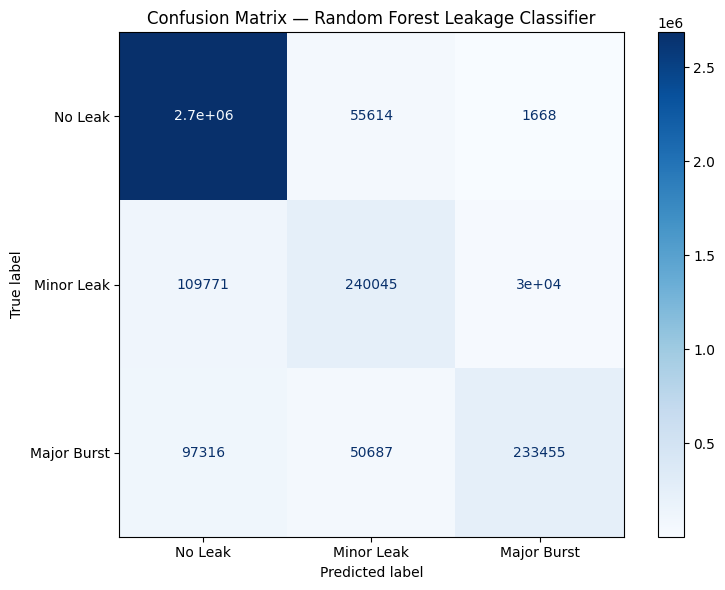

Confusion matrix saved.


In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Leak", "Minor Leak", "Major Burst"]
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Random Forest Leakage Classifier")
plt.tight_layout()
plt.savefig(DATA_PATH / "confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved.")

# Feature importance


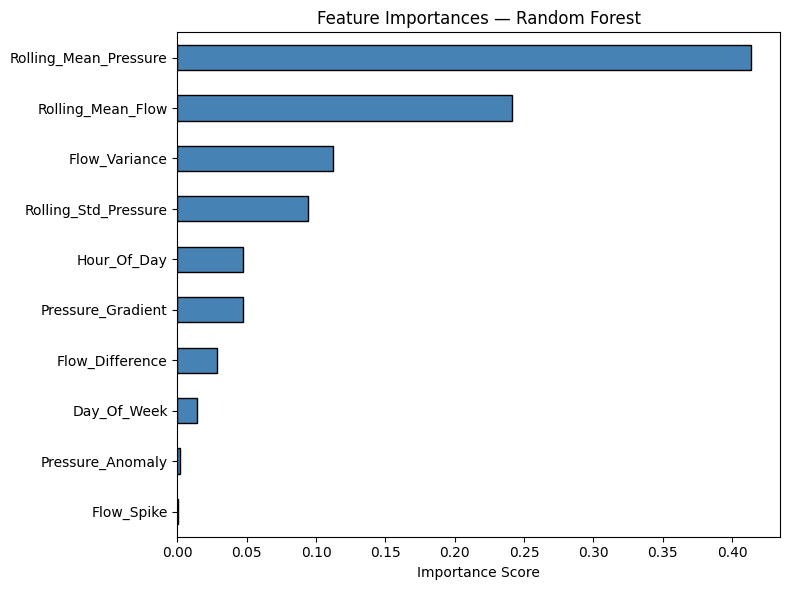


Feature importances:
Rolling_Mean_Pressure    0.413924
Rolling_Mean_Flow        0.241196
Flow_Variance            0.112016
Rolling_Std_Pressure     0.093834
Hour_Of_Day              0.047176
Pressure_Gradient        0.047160
Flow_Difference          0.028857
Day_Of_Week              0.013755
Pressure_Anomaly         0.001509
Flow_Spike               0.000572
dtype: float64


In [11]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", color="steelblue", edgecolor="black", ax=ax)
ax.set_title("Feature Importances — Random Forest")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(DATA_PATH / "feature_importances.png", dpi=150)
plt.show()

print("\nFeature importances:")
print(importances.sort_values(ascending=False))

# Save model

In [18]:
import joblib

model_path = DATA_PATH / "rf_leakage_classifier.pkl"
joblib.dump(rf_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: C:\Users\Hp\water_leakage_ml\data\Net1_CMH\rf_leakage_classifier.pkl


# Optimising the model
### Retrain model with larger sample to improve recall

In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# ── Step 1: Increased stratified sample ────────────────────────
SAMPLE_PER_CLASS = 500_000

print("Taking increased stratified sample...")
sampled_parts = []

for label in sorted(y_train.unique()):
    idx = y_train[y_train == label].index
    n = min(SAMPLE_PER_CLASS, len(idx))
    sampled_idx = np.random.RandomState(42).choice(idx, size=n, replace=False)
    sampled_parts.append((X_train.loc[sampled_idx], y_train.loc[sampled_idx]))

X_train_sample2 = pd.concat([s[0] for s in sampled_parts])
y_train_sample2 = pd.concat([s[1] for s in sampled_parts])

print("Sample class distribution:")
print(y_train_sample2.value_counts().sort_index())
print(f"Total sample size: {len(X_train_sample2):,}")

Taking increased stratified sample...
Sample class distribution:
Label
0    500000
1    500000
2    500000
Name: count, dtype: int64
Total sample size: 1,500,000


In [13]:
print("Applying SMOTE...")

smote2 = SMOTE(random_state=42)
X_train_resampled2, y_train_resampled2 = smote2.fit_resample(
    X_train_sample2, y_train_sample2
)

print(f"\nAfter SMOTE — class distribution:")
print(pd.Series(y_train_resampled2).value_counts().sort_index())
print(f"Final training size: {X_train_resampled2.shape}")

Applying SMOTE...

After SMOTE — class distribution:
Label
0    500000
1    500000
2    500000
Name: count, dtype: int64
Final training size: (1500000, 10)


# Increased class weights

In [14]:
print("Training improved Random Forest...")

rf_model_v2 = RandomForestClassifier(
    n_estimators=200,         # more trees for better generalisation
    max_depth=25,             # slightly deeper trees
    min_samples_split=8,
    min_samples_leaf=3,
    class_weight={0: 1, 1: 3, 2: 3},  # penalise missed leaks more heavily
    random_state=42,
    n_jobs=-1
)

rf_model_v2.fit(X_train_resampled2, y_train_resampled2)
print("Training complete.")

Training improved Random Forest...
Training complete.


# Test evaluation on retrained model

In [15]:
y_pred_v2 = rf_model_v2.predict(X_test)

print("Improved Model Classification Report:")
print(classification_report(
    y_test, y_pred_v2,
    target_names=["No Leak (0)", "Minor Leak (1)", "Major Burst (2)"]
))

weighted_f1_v2 = f1_score(y_test, y_pred_v2, average="weighted")
macro_f1_v2 = f1_score(y_test, y_pred_v2, average="macro")
print(f"Weighted F1: {weighted_f1_v2:.4f}")
print(f"Macro F1:    {macro_f1_v2:.4f}")

Improved Model Classification Report:
                 precision    recall  f1-score   support

    No Leak (0)       0.94      0.83      0.88   2742150
 Minor Leak (1)       0.36      0.72      0.48    380192
Major Burst (2)       0.80      0.65      0.71    381458

       accuracy                           0.80   3503800
      macro avg       0.70      0.73      0.69   3503800
   weighted avg       0.86      0.80      0.82   3503800

Weighted F1: 0.8187
Macro F1:    0.6902


In [16]:
print("=" * 55)
print(f"{'Metric':<25} {'V1':>10} {'V2':>10} {'Change':>10}")
print("=" * 55)

v1_report = classification_report(
    y_test, y_pred,
    target_names=["No Leak", "Minor Leak", "Major Burst"],
    output_dict=True
)
v2_report = classification_report(
    y_test, y_pred_v2,
    target_names=["No Leak", "Minor Leak", "Major Burst"],
    output_dict=True
)

metrics = [
    ("No Leak F1",      v1_report["No Leak"]["f1-score"],      v2_report["No Leak"]["f1-score"]),
    ("Minor Leak F1",   v1_report["Minor Leak"]["f1-score"],   v2_report["Minor Leak"]["f1-score"]),
    ("Major Burst F1",  v1_report["Major Burst"]["f1-score"],  v2_report["Major Burst"]["f1-score"]),
    ("Weighted F1",     v1_report["weighted avg"]["f1-score"], v2_report["weighted avg"]["f1-score"]),
    ("Macro F1",        v1_report["macro avg"]["f1-score"],    v2_report["macro avg"]["f1-score"]),
]

for name, v1, v2 in metrics:
    change = v2 - v1
    arrow = "▲" if change > 0 else "▼"
    print(f"{name:<25} {v1:>10.4f} {v2:>10.4f} {arrow}{abs(change):>8.4f}")

print("=" * 55)

Metric                            V1         V2     Change
No Leak F1                    0.9531     0.8808 ▼  0.0722
Minor Leak F1                 0.6608     0.4771 ▼  0.1837
Major Burst F1                0.7217     0.7127 ▼  0.0090
Weighted F1                   0.8962     0.8187 ▼  0.0774
Macro F1                      0.7785     0.6902 ▼  0.0883


# Save better model

In [17]:
import joblib

# Save whichever has the higher macro F1
if macro_f1_v2 > f1_score(y_test, y_pred, average="macro"):
    joblib.dump(rf_model_v2, DATA_PATH / "rf_leakage_classifier.pkl")
    print("V2 model is better — saved as rf_leakage_classifier.pkl")
else:
    print("V1 model was already better — keeping original")

V1 model was already better — keeping original
